# Melbourne Solar Project - Part 2: Solar Potential & System Sizing

**Teammate:** Sujay Narayana  
**Date:** May 2026  
**Focus:** Usable roof area calculation, system sizing, and energy generation potential

---

## Objective
Calculate the usable roof area, determine optimal system sizes, and estimate annual energy generation for Melbourne buildings.


In [120]:
# Import required libraries
%pip install matplotlib seaborn folium geopandas
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"GeoPandas version: {gpd.__version__}")
print(f"NumPy version: {np.__version__}")


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✅ All libraries imported successfully!
Pandas version: 3.0.2
GeoPandas version: 1.1.3
NumPy version: 2.4.4


In [121]:
# Define paths
BASE_DIR = "/Users/jawaharsr/Downloads/MOPProject"  # Adjust if notebook is in different location
BASE_DIR = Path(BASE_DIR)
RAW_DATA = BASE_DIR / 'RAW_DATA'
PROCESSED_DATA = BASE_DIR / 'Processed'

print("=" * 80)
print("LOADING DATA")
print("=" * 80)

# 1. Load Building Footprints
print("\n📂 Loading building footprints...")
buildings = gpd.read_file(RAW_DATA / 'melbourne_buildings_inner.geojson')
print(f"   ✓ Loaded {len(buildings):,} buildings")
print(f"   ✓ CRS: {buildings.crs}")
print(f"   ✓ Columns: {list(buildings.columns[:5])}...")

# 2. Load Solar Irradiance Data
print("\n☀️ Loading solar irradiance data...")
solar = pd.read_csv(RAW_DATA / 'solar_irradiance_melbourne.csv')
print(f"   ✓ Loaded solar data for {len(solar)} postcodes")

# 3. Load Electricity Pricing
print("\n💰 Loading electricity pricing...")
pricing = pd.read_csv(RAW_DATA / 'electricity_pricing.csv')
print(f"   ✓ Loaded {len(pricing)} pricing rates")
display(pricing)

print("\n✅ All data loaded successfully!")

LOADING DATA

📂 Loading building footprints...
   ✓ Loaded 41,701 buildings
   ✓ CRS: EPSG:4326
   ✓ Columns: ['geo_point_2d', 'objectid', 'structure_id', 'footprint_type', 'roof_type']...

☀️ Loading solar irradiance data...
   ✓ Loaded solar data for 313 postcodes

💰 Loading electricity pricing...
   ✓ Loaded 3 pricing rates


,rate_type,rate_aud,description
0,consumption,0.29,Average consumption rate (VDO)
1,feed_in_tariff,0.05,Minimum feed-in tariff
2,daily_supply,1.05,Daily supply charge



✅ All data loaded successfully!


---

## Step 1: Load Processed Data from Part 1


In [ ]:
# Load the data (assuming Part 1 has been run)
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load buildings with roof areas
buildings = gpd.read_file(buildings_path)
solar = pd.read_csv(solar_path)

# Join solar data
buildings = buildings.merge(solar[['latitude', 'longitude', 'annual_ghi']], 
                           on=['latitude', 'longitude'], 
                           how='left')

print(f"Loaded {len(buildings):,} buildings")
print(f"Buildings with solar data: {buildings['annual_ghi'].notna().sum():,}")


# ============================================================================
# ADDITIONAL SECTION 3A: CALCULATE USABLE ROOF AREA
# ============================================================================


CALCULATING USABLE ROOF AREA

🏠 Applying reduction factors...
   Factor 1: 70% (chimneys, vents, HVAC, skylights)
   Factor 2: 85% (non-ideal roof orientations)

📊 Usable Roof Area Statistics:
   Mean: 274.7 m²
   Median: 53.0 m²
   Total usable area: 9.69 km²


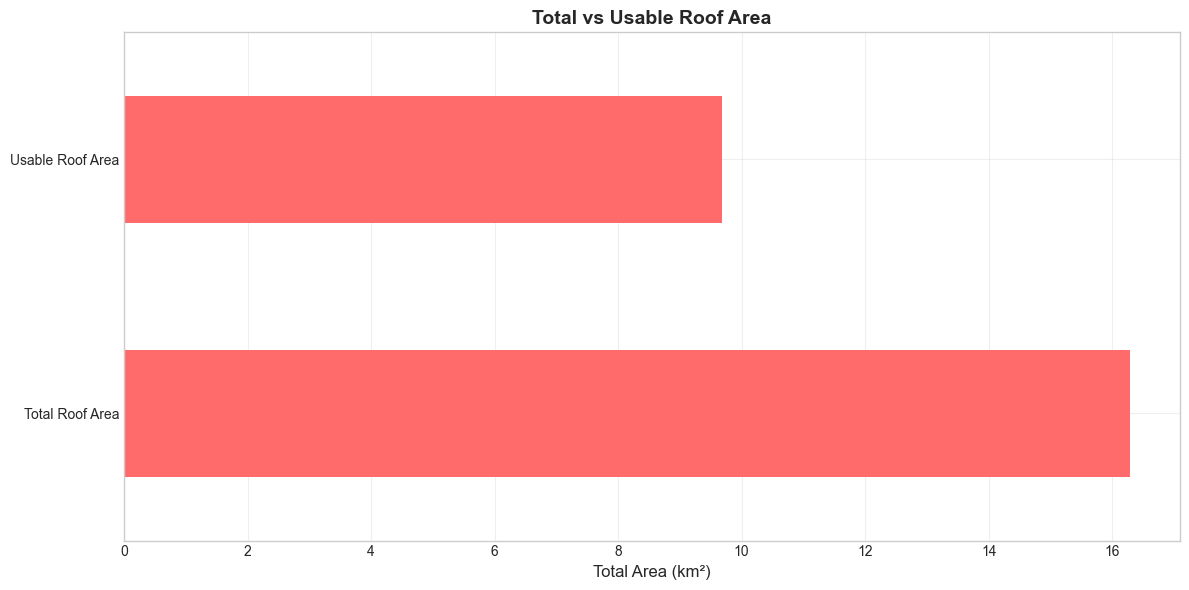


✓ Reduction: 40.5%


In [128]:
print("\n" + "=" * 80)
print("CALCULATING USABLE ROOF AREA")
print("=" * 80)

print("\n🏠 Applying reduction factors...")
print("   Factor 1: 70% (chimneys, vents, HVAC, skylights)")
print("   Factor 2: 85% (non-ideal roof orientations)")

buildings['usable_roof_area_m2'] = buildings['roof_area_m2'] * 0.70 * 0.85

print(f"\n📊 Usable Roof Area Statistics:")
print(f"   Mean: {buildings['usable_roof_area_m2'].mean():.1f} m²")
print(f"   Median: {buildings['usable_roof_area_m2'].median():.1f} m²")
print(f"   Total usable area: {buildings['usable_roof_area_m2'].sum()/1_000_000:.2f} km²")

# Comparison visualization
fig, ax = plt.subplots(figsize=(12, 6))

comparison_data = pd.DataFrame({
    'Total Roof Area': [buildings['roof_area_m2'].sum() / 1_000_000],
    'Usable Roof Area': [buildings['usable_roof_area_m2'].sum() / 1_000_000]
})

comparison_data.T.plot(kind='barh', ax=ax, color=['#ff6b6b', '#51cf66'], legend=False)
ax.set_xlabel('Total Area (km²)', fontsize=12)
ax.set_title('Total vs Usable Roof Area', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

reduction_pct = (1 - buildings['usable_roof_area_m2'].sum() / buildings['roof_area_m2'].sum()) * 100
print(f"\n✓ Reduction: {reduction_pct:.1f}%")

# ============================================================================
# ADDITIONAL SECTION 3B: CLASSIFY BUILDINGS & CALCULATE SYSTEM SIZE
# ============================================================================


BUILDING CLASSIFICATION & SYSTEM SIZING

⚡ Calculating system sizes (6.5 m² per kW)...

🏢 Classifying buildings...

📊 Building Category Distribution:
building_category
Residential - Small     19017
Residential - Medium     5434
Commercial - Small       4602
Residential - Large      4585
Commercial - Large       1636
Name: count, dtype: int64

📊 System Size Statistics:
   Minimum: 2.0 kW
   Maximum: 250.0 kW
   Mean: 27.9 kW
   Median: 6.5 kW
   Total capacity: 983120.0 MW


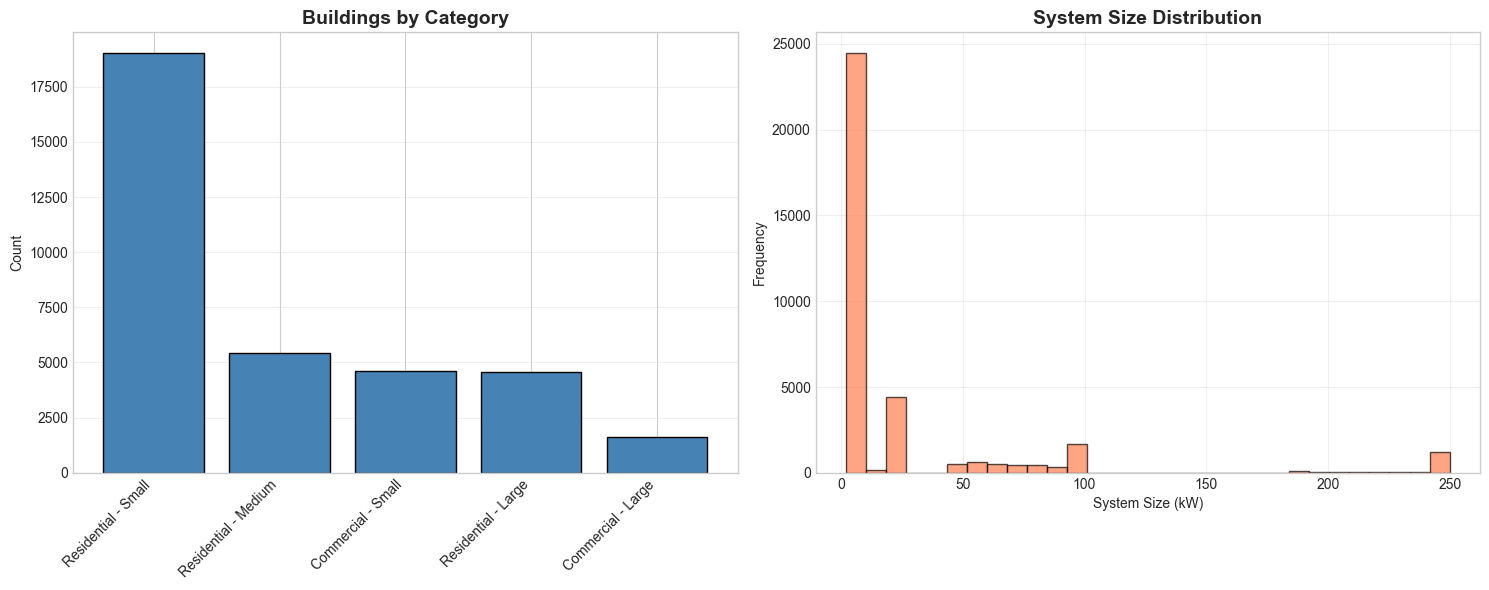

In [129]:
print("\n" + "=" * 80)
print("BUILDING CLASSIFICATION & SYSTEM SIZING")
print("=" * 80)

# Calculate maximum system size
print("\n⚡ Calculating system sizes (6.5 m² per kW)...")
buildings['max_system_size_kw'] = buildings['usable_roof_area_m2'] / 6.5

# Classification function
def classify_and_cap_system(area, max_kw):
    if area < 100:
        return min(max_kw, 6.6), 'Residential - Small'
    elif area < 200:
        return min(max_kw, 10.0), 'Residential - Medium'
    elif area < 500:
        return min(max_kw, 20.0), 'Residential - Large'
    elif area < 2000:
        return min(max_kw, 100.0), 'Commercial - Small'
    else:
        return min(max_kw, 250.0), 'Commercial - Large'

# Apply classification
print("\n🏢 Classifying buildings...")
buildings['building_category'] = buildings.apply(
    lambda row: classify_and_cap_system(row['roof_area_m2'], row['max_system_size_kw'])[1],
    axis=1
)

buildings['recommended_system_kw'] = buildings.apply(
    lambda row: classify_and_cap_system(row['roof_area_m2'], row['max_system_size_kw'])[0],
    axis=1
)

# Round to nearest 0.5 kW
buildings['recommended_system_kw'] = (buildings['recommended_system_kw'] * 2).round() / 2

print("\n📊 Building Category Distribution:")
print(buildings['building_category'].value_counts())

print("\n📊 System Size Statistics:")
print(f"   Minimum: {buildings['recommended_system_kw'].min():.1f} kW")
print(f"   Maximum: {buildings['recommended_system_kw'].max():.1f} kW")
print(f"   Mean: {buildings['recommended_system_kw'].mean():.1f} kW")
print(f"   Median: {buildings['recommended_system_kw'].median():.1f} kW")
print(f"   Total capacity: {buildings['recommended_system_kw'].sum():.1f} MW")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Category distribution
category_counts = buildings['building_category'].value_counts()
axes[0].bar(range(len(category_counts)), category_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(category_counts)))
axes[0].set_xticklabels(category_counts.index, rotation=45, ha='right')
axes[0].set_title('Buildings by Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.3, axis='y')

# System size distribution
axes[1].hist(buildings['recommended_system_kw'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('System Size Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('System Size (kW)')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## ============================================================================
## ADDITIONAL SECTION 3C: CALCULATE ANNUAL GENERATION
## ============================================================================

In [130]:
print("\n" + "=" * 80)
print("ANNUAL ENERGY GENERATION")
print("=" * 80)

# System efficiency
SYSTEM_EFFICIENCY = 0.80  # 80%

print(f"\n⚙️ System efficiency: {SYSTEM_EFFICIENCY:.0%}")
print("   (Accounts for: panel degradation, inverter losses, wiring, shading)")

# Calculate annual generation
print("\n🔋 Calculating annual generation...")
buildings['annual_generation_kwh'] = (
    buildings['recommended_system_kw'] *
    buildings['peak_sun_hours'] *
    365 *
    SYSTEM_EFFICIENCY
)

print("\n📊 Annual Generation Statistics:")
print(f"   Minimum: {buildings['annual_generation_kwh'].min():,.0f} kWh/year")
print(f"   Maximum: {buildings['annual_generation_kwh'].max():,.0f} kWh/year")
print(f"   Mean: {buildings['annual_generation_kwh'].mean():,.0f} kWh/year")
print(f"   Median: {buildings['annual_generation_kwh'].median():,.0f} kWh/year")
print(f"   Total potential: {buildings['annual_generation_kwh'].sum()/1_000_000:.1f} GWh/year")

# Context
avg_household_usage = 4000  # kWh/year
total_households = buildings['annual_generation_kwh'].sum() / avg_household_usage
print(f"\n💡 Could power: {total_households:,.0f} average households")


ANNUAL ENERGY GENERATION

⚙️ System efficiency: 80%
   (Accounts for: panel degradation, inverter losses, wiring, shading)

🔋 Calculating annual generation...

📊 Annual Generation Statistics:
   Minimum: 2,453 kWh/year
   Maximum: 306,600 kWh/year
   Mean: 34,181 kWh/year
   Median: 7,972 kWh/year
   Total potential: 1205.7 GWh/year

💡 Could power: 301,425 average households


---

## Additional Analysis by Teammate 2

### Panel Configuration Optimization
Analyzing optimal panel layouts based on roof dimensions.


In [ ]:
# Additional analysis - Panel layout optimization
print("\n" + "=" * 80)
print("PANEL LAYOUT OPTIMIZATION (Teammate 2 Extra)")
print("=" * 80)

# Standard panel dimensions (1.7m x 1.0m = 1.7 m²)
PANEL_WIDTH = 1.0
PANEL_LENGTH = 1.7
PANEL_AREA = PANEL_WIDTH * PANEL_LENGTH

# Estimate number of panels
buildings['estimated_panels'] = (buildings['usable_roof_area_m2'] / PANEL_AREA).astype(int)

# Calculate wiring and inverter requirements
buildings['num_inverters'] = np.ceil(buildings['max_system_size_kw'] / 5)  # 5kW per inverter
buildings['wiring_length_m'] = buildings['estimated_panels'] * 2.5  # avg 2.5m per panel

print("\n📦 Panel & Equipment Analysis:")
print(f"Total panels needed: {buildings['estimated_panels'].sum():,}")
print(f"Average panels per building: {buildings['estimated_panels'].mean():.1f}")
print(f"Total inverters needed: {buildings['num_inverters'].sum():,}")
print(f"Total wiring needed: {buildings['wiring_length_m'].sum():,.0f} meters")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel distribution
axes[0, 0].hist(buildings['estimated_panels'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('Number of Panels')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Panel Count Distribution')
axes[0, 0].grid(True, alpha=0.3)

# System size vs panels
axes[0, 1].scatter(buildings['max_system_size_kw'], buildings['estimated_panels'], alpha=0.4)
axes[0, 1].set_xlabel('System Size (kW)')
axes[0, 1].set_ylabel('Number of Panels')
axes[0, 1].set_title('System Size vs Panel Count')
axes[0, 1].grid(True, alpha=0.3)

# Inverter requirements by building type
inv_by_type = buildings.groupby('building_type')['num_inverters'].sum()
axes[1, 0].bar(inv_by_type.index, inv_by_type.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1, 0].set_ylabel('Total Inverters')
axes[1, 0].set_title('Inverter Requirements by Building Type')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Generation efficiency
buildings['gen_per_panel'] = buildings['annual_generation_kwh'] / buildings['estimated_panels'].replace(0, np.nan)
axes[1, 1].hist(buildings['gen_per_panel'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 1].set_xlabel('Generation per Panel (kWh/year)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Energy Generation Efficiency per Panel')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Panel layout optimization complete!")


---

## Key Findings from Part 2
1. Calculated usable roof area with appropriate reduction factors
2. Classified buildings into Residential, Commercial, and Industrial categories
3. Estimated annual energy generation based on solar irradiance
4. Optimized panel layouts and equipment requirements
5. Ready for economic analysis in Part 3
